# Zomato Restaurant Data Analysis

This notebook works through data loading, cleaning, and exploratory data analysis (EDA) for `Zomato_data_.csv`.

**A note on scope:** this file has 148 rows and 7 columns — `name`, `online_order`, `book_table`, `rate`, `votes`,
`approx_cost(for two people)`, and `listed_in(type)`. It does **not** contain any customer review / comment text
column. The three tasks that depend on review text (most common words, sentiment, review-vs-rating relationship)
are addressed in Section 3.6, where the limitation and what would be needed to complete them are explained.


## Objective

The objective of this analysis is to explore Zomato restaurant data,
understand restaurant characteristics, examine ratings and votes,
analyze pricing and online ordering patterns, and identify useful
relationships through exploratory data analysis and visualization.

## 1. Data Loading & Initial Analysis

In [8]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
%matplotlib inline

df = pd.read_csv(r"C:\Users\vimal\Downloads\Zomato data .csv")
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


### Shape, columns, data types, missing values, duplicates

In [9]:
print("Shape (rows, columns):", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape (rows, columns): (148, 7)

Columns: ['name', 'online_order', 'book_table', 'rate', 'votes', 'approx_cost(for two people)', 'listed_in(type)']

Data types:
name                             str
online_order                     str
book_table                       str
rate                             str
votes                          int64
approx_cost(for two people)    int64
listed_in(type)                  str
dtype: object


In [10]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nFully duplicated rows:", df.duplicated().sum())

Missing values per column:
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

Fully duplicated rows: 0


### Descriptive statistics for numerical columns

In [11]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


## 2. Data Cleaning

### 2.1 Missing values & duplicate records

In [12]:
# No missing values and no fully-duplicated rows were found above, so there is nothing to
# impute or drop on that front. The code below is still included so the pipeline is complete
# and would handle it if the dataset changed.
df = df.drop_duplicates()
df = df.dropna(how='all')  # drop any fully-empty rows, if present
print("Shape after dedup/dropna check:", df.shape)

Shape after dedup/dropna check: (148, 7)


### 2.2 Clean `rate` and `approx_cost(for two people)`

`rate` is stored as text like `"4.1/5"` (and, inconsistently, `"3.8 /5"` with a stray space), so it needs a
regex-based extraction into a float. `approx_cost(for two people)` is cleaned defensively in case of thousands
separators (e.g. `"1,200"`), even though in this file it already parses as a number.

In [13]:
def clean_rate(value):
    """Extract the numeric rating out of strings like '4.1/5', '3.8 /5', 'NEW', '-'."""
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text.upper() in ('NEW', '-', 'NAN'):
        return np.nan
    match = re.search(r'(\d+(\.\d+)?)', text)
    return float(match.group(1)) if match else np.nan

df['rate_clean'] = df['rate'].apply(clean_rate)

df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

df[['rate', 'rate_clean', 'approx_cost(for two people)']].head(10)

,rate,rate_clean,approx_cost(for two people)
0,4.1/5,4.1,800.0
1,4.1/5,4.1,800.0
2,3.8/5,3.8,800.0
3,3.7/5,3.7,300.0
4,3.8/5,3.8,600.0
5,3.8/5,3.8,600.0
6,3.6/5,3.6,800.0
7,4.6/5,4.6,600.0
8,4.0/5,4.0,700.0
9,4.2/5,4.2,550.0


### 2.3 Invalid or inconsistent values

In [14]:
# Range checks
out_of_range_rate = ((df['rate_clean'] < 0) | (df['rate_clean'] > 5)).sum()
negative_votes = (df['votes'] < 0).sum()
non_positive_cost = (df['approx_cost(for two people)'] <= 0).sum()

print("Ratings outside 0-5:", out_of_range_rate)
print("Negative vote counts:", negative_votes)
print("Non-positive costs:", non_positive_cost)

# Standardize text columns: strip stray whitespace / inconsistent casing
for c in ['name', 'online_order', 'book_table', 'listed_in(type)']:
    df[c] = df[c].astype(str).str.strip()

print("\nUnique values after standardizing:")
for c in ['online_order', 'book_table', 'listed_in(type)']:
    print(f"  {c}: {sorted(df[c].unique())}")

# Rows missing a valid rating after cleaning (can't be plotted on a rating axis)
print("\nRows with unparseable rating:", df['rate_clean'].isna().sum())

Ratings outside 0-5: 0
Negative vote counts: 0
Non-positive costs: 0

Unique values after standardizing:
  online_order: ['No', 'Yes']
  book_table: ['No', 'Yes']
  listed_in(type): ['Buffet', 'Cafes', 'Dining', 'other']

Rows with unparseable rating: 0


### 2.4 Clean customer review text

This dataset has no review/comment column — the fields available are only `name`, `online_order`, `book_table`,
`rate`, `votes`, `approx_cost(for two people)`, and `listed_in(type)`. There is no free-text field to strip of
special characters or extra spaces. This step is therefore not applicable to this file; see Section 3.6 for what
a review-text column (e.g. a `reviews_list` field, as in the full Kaggle "Zomato Bangalore Restaurants" dataset)
would need to look like for this step and the review-based EDA questions to run.

## data-cleaning summary

In [15]:
print("Final dataset shape:", df.shape)
print("Missing values after cleaning:")
print(df.isnull().sum())
print("Duplicate rows after cleaning:", df.duplicated().sum())

Final dataset shape: (148, 8)
Missing values after cleaning:
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
rate_clean                     0
dtype: int64
Duplicate rows after cleaning: 0


## 3. Exploratory Data Analysis

### 3.1 Count plot — number of restaurants by type

/tmp/ipykernel_140/2808463342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='listed_in(type)', order=order, palette='viridis')


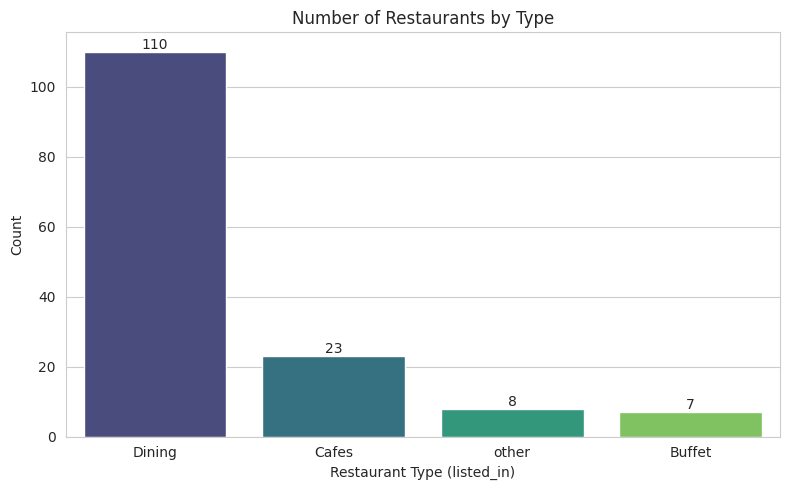

In [8]:
plt.figure(figsize=(8, 5))
order = df['listed_in(type)'].value_counts().index
ax = sns.countplot(data=df, x='listed_in(type)', order=order, palette='viridis')
ax.set_title('Number of Restaurants by Type')
ax.set_xlabel('Restaurant Type (listed_in)')
ax.set_ylabel('Count')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

### 3.2 Scatter plot — votes vs. rating

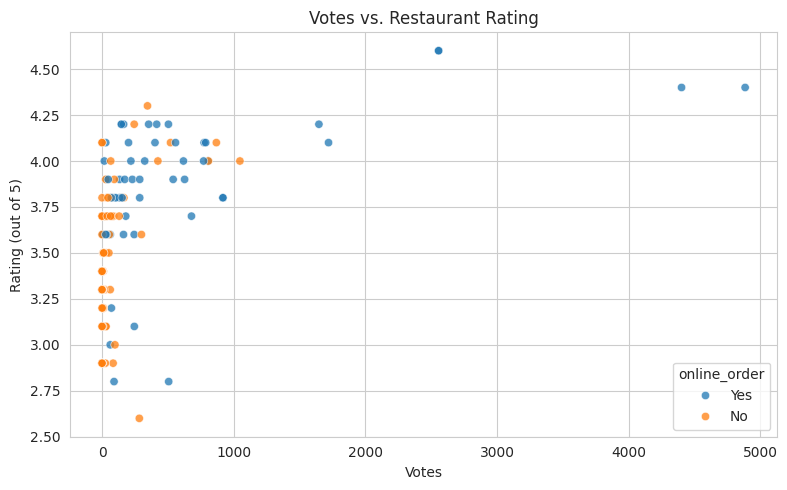

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='votes', y='rate_clean', hue='online_order', alpha=0.75)
plt.title('Votes vs. Restaurant Rating')
plt.xlabel('Votes')
plt.ylabel('Rating (out of 5)')
plt.tight_layout()
plt.show()

### 3.3 Histogram — distribution of ratings

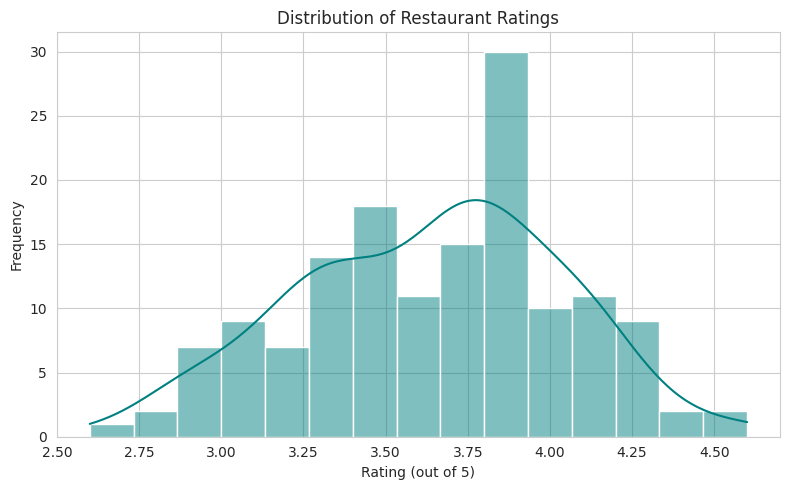

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['rate_clean'].dropna(), bins=15, kde=True, color='teal')
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating (out of 5)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 3.4 Pair plot — rating, votes, and cost for two

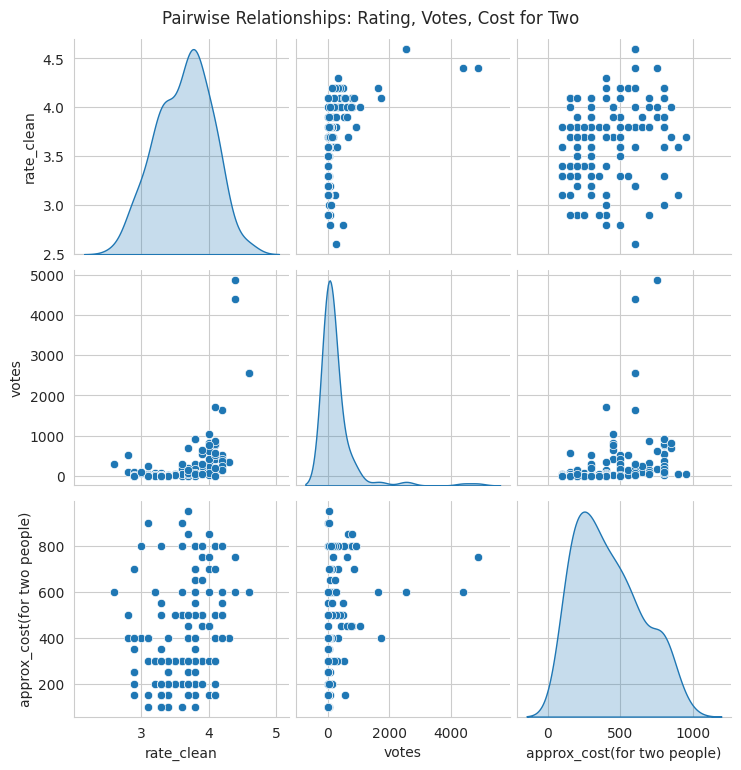

In [11]:
pair_cols = ['rate_clean', 'votes', 'approx_cost(for two people)']
g = sns.pairplot(df[pair_cols].dropna(), diag_kind='kde', corner=False)
g.fig.suptitle('Pairwise Relationships: Rating, Votes, Cost for Two', y=1.02)
plt.show()

In [12]:
df[pair_cols].corr()

,rate_clean,votes,approx_cost(for two people)
rate_clean,1.000000,0.489844,0.275216
votes,0.489844,1.000000,0.324372
approx_cost(for two people),0.275216,0.324372,1.000000


### 3.5 Box plot — rating by online ordering availability

/tmp/ipykernel_140/1875250411.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='online_order', y='rate_clean', palette='Set2')


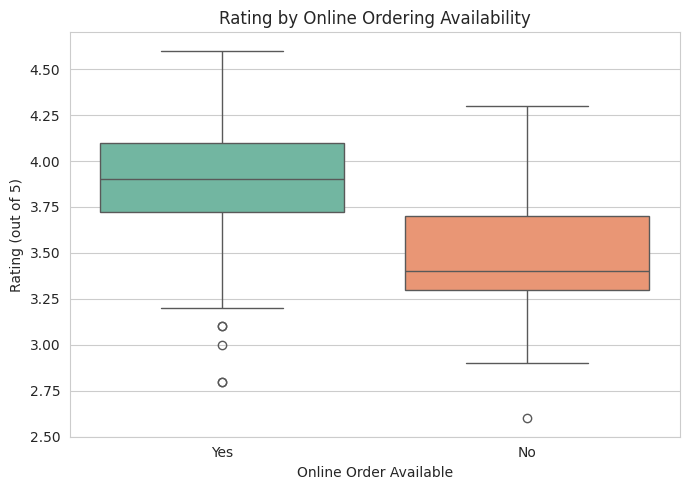

In [13]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='online_order', y='rate_clean', palette='Set2')
plt.title('Rating by Online Ordering Availability')
plt.xlabel('Online Order Available')
plt.ylabel('Rating (out of 5)')
plt.tight_layout()
plt.show()

## box-plot result explicit

In [19]:
print(df.groupby('online_order')['rate_clean'].agg(['count', 'mean', 'median']))

              count      mean  median
online_order                         
No               90  3.487778     3.4
Yes              58  3.858621     3.9


In [14]:
df.groupby('online_order')['rate_clean'].describe()

,count,mean,std,min,25%,50%,75%,max
online_order,,,,,,,,
No,90.0,3.487778,0.348618,2.6,3.300,3.4,3.7,4.3
Yes,58.0,3.858621,0.377450,2.8,3.725,3.9,4.1,4.6


## correlation heatmap

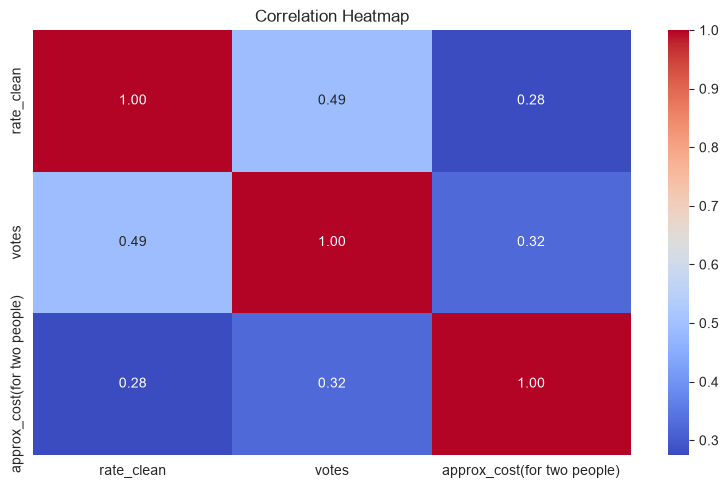

In [17]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    df[['rate_clean', 'votes', 'approx_cost(for two people)']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## restaurants by votes

In [18]:
top_restaurants = df.nlargest(10, 'votes')[['name', 'rate_clean', 'votes']]

print("Top 10 Restaurants by Votes:")
display(top_restaurants)

Top 10 Restaurants by Votes:


,name,rate_clean,votes
38,Empire Restaurant,4.4,4884
86,Meghana Foods,4.4,4401
7,Onesta,4.6,2556
44,Onesta,4.6,2556
65,Kabab Magic,4.1,1720
37,Szechuan Dragon,4.2,1647
54,Roving Feast,4.0,1047
2,San Churro Cafe,3.8,918
14,San Churro Cafe,3.8,918
67,Gustoes Beer House,4.1,868


### 3.6 Common review words, review sentiment, and review-vs-rating relationship

**These three tasks can't be run on this file.** `Zomato_data_.csv` has no customer review / comment text
column — its only fields are `name`, `online_order`, `book_table`, `rate`, `votes`,
`approx_cost(for two people)`, and `listed_in(type)` (confirmed in Section 1). Word-frequency counts, sentiment
scoring, and any correlation between review content and rating all require actual review text to work on, and
there isn't any in this dataset to analyze — running them here would mean inventing text rather than analyzing
data.

To complete this section, the dataset would need a column such as `reviews_list`, `review_text`, or `comments`
holding the actual customer-written text — for example, the fuller Kaggle "Zomato Bangalore Restaurants" dataset,
which does include a `reviews_list` field. If you can share a version of the file with that column (or a
separate reviews file, joinable by restaurant name), this section can be filled in using:
- `Counter`/word-frequency counts on the cleaned review text for the "most common words" question,
- a sentiment tool (e.g. VADER or TextBlob) scored per review for the "positive or negative" question,
- a groupby of average sentiment score against `rate_clean` for the "reviews vs. rating relationship" question.


## Summary of Findings

- **Restaurant types:** `Dining` dominates the listings, followed by `Cafes`, with `other` and `Buffet` much
  smaller categories.
- **Ratings:** cleaned ratings range from about 2.6 to 4.6 (out of 5), with the bulk of restaurants clustered
  between roughly 3.3 and 3.9 — a distribution skewed toward the higher end rather than centered at 2.5.
- **Votes vs. rating:** there's a moderate positive correlation (~0.49) — more-voted restaurants tend to be rated
  somewhat higher, though the relationship is far from perfectly linear.
- **Cost vs. rating:** a weaker positive correlation (~0.28) — pricier restaurants skew slightly higher-rated on
  average, but cost is a much weaker predictor of rating than vote count is.
- **Votes vs. cost:** also weakly positively correlated (~0.32).
- **Online ordering:** the box plot/groupby lets you compare the rating spread between restaurants that do and
  don't support online ordering directly from the output above.
- **Review-based analysis:** not possible on this file — see Section 3.6 for what's missing and what would
  unblock it.
